# Homework 10: Review and Final Project Work

**Author:** Lei Wu  
**Date:** 2023-01-01  
**Version:** 1.0.0

## Assignment Overview
This homework assignment serves as a comprehensive review of all course concepts and provides a framework for the final project.

## Learning Objectives
- Review and integrate all course concepts
- Apply data science workflow to real-world problems
- Create a comprehensive data analysis project
- Present findings effectively
- Demonstrate mastery of Python data science tools

## Instructions
1. Complete all exercises in order
2. Run all code cells and ensure they execute without errors
3. Answer all written questions thoroughly
4. Submit your completed notebook

---

## Exercise 1: Comprehensive Data Analysis Project (40 points)

**Task:** Create a complete data analysis project using all course concepts.

**Requirements:**
- Choose a dataset and define analysis goals
- Perform exploratory data analysis
- Apply data preprocessing and cleaning
- Build and evaluate machine learning models
- Create visualizations and present findings


=== COMPREHENSIVE DATA ANALYSIS PROJECT ===
Project: Wine Quality Classification
Objective: Build a machine learning model to classify wine quality

1. DATA LOADING AND EXPLORATION
----------------------------------------
Dataset shape: (178, 15)
Features: ['alcohol', 'malic_acid', 'ash', 'alcalinity_of_ash', 'magnesium', 'total_phenols', 'flavanoids', 'nonflavanoid_phenols', 'proanthocyanins', 'color_intensity', 'hue', 'od280/od315_of_diluted_wines', 'proline']
Target classes: ['class_0' 'class_1' 'class_2']

Dataset Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 178 entries, 0 to 177
Data columns (total 15 columns):
 #   Column                        Non-Null Count  Dtype  
---  ------                        --------------  -----  
 0   alcohol                       178 non-null    float64
 1   malic_acid                    178 non-null    float64
 2   ash                           178 non-null    float64
 3   alcalinity_of_ash             178 non-null    float64
 4   magnes

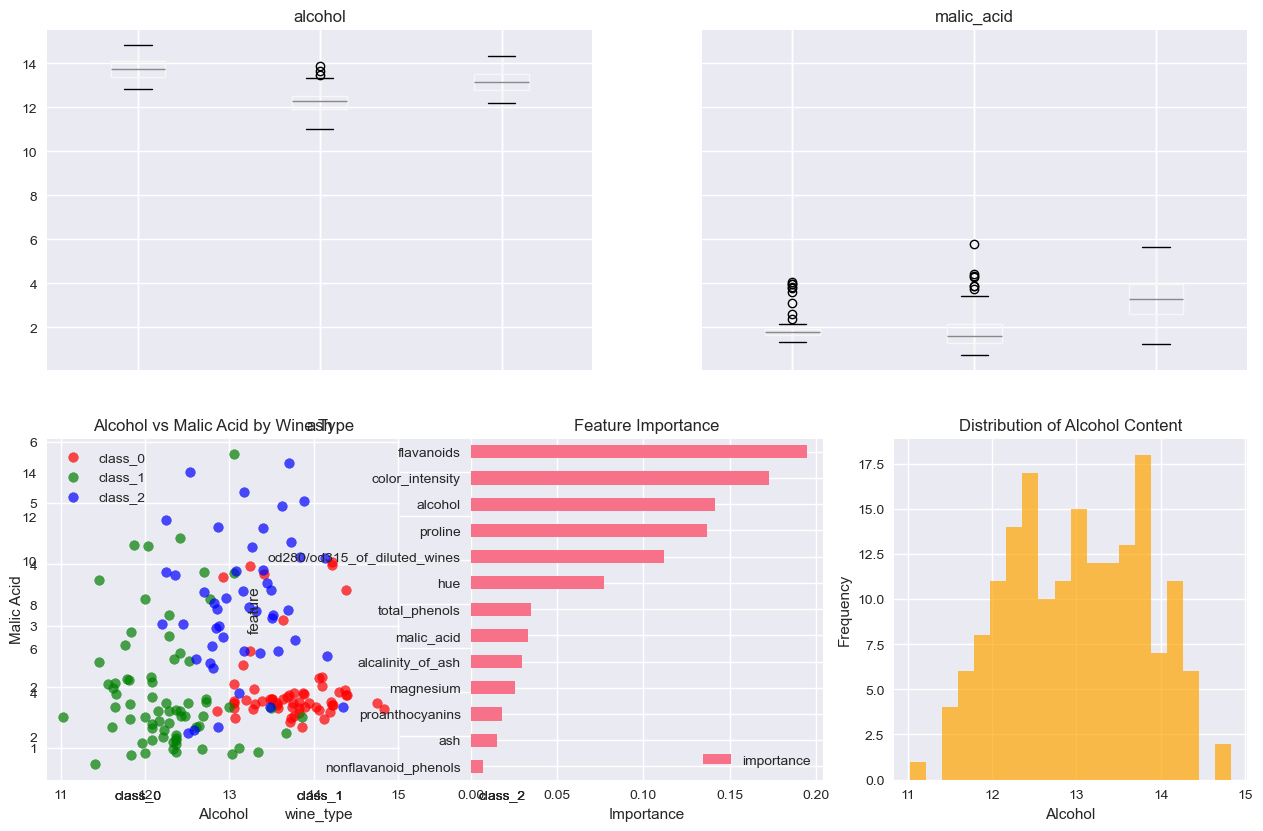


3. DATA PREPROCESSING
----------------------------------------
Original features shape: (178, 13)
Scaled features shape: (178, 13)
Scaled features (first 5 rows):
    alcohol  malic_acid       ash  alcalinity_of_ash  magnesium  \
0  1.518613   -0.562250  0.232053          -1.169593   1.913905   
1  0.246290   -0.499413 -0.827996          -2.490847   0.018145   
2  0.196879    0.021231  1.109334          -0.268738   0.088358   
3  1.691550   -0.346811  0.487926          -0.809251   0.930918   
4  0.295700    0.227694  1.840403           0.451946   1.281985   

   total_phenols  flavanoids  nonflavanoid_phenols  proanthocyanins  \
0       0.808997    1.034819             -0.659563         1.224884   
1       0.568648    0.733629             -0.820719        -0.544721   
2       0.808997    1.215533             -0.498407         2.135968   
3       2.491446    1.466525             -0.981875         1.032155   
4       0.808997    0.663351              0.226796         0.401404   

   col

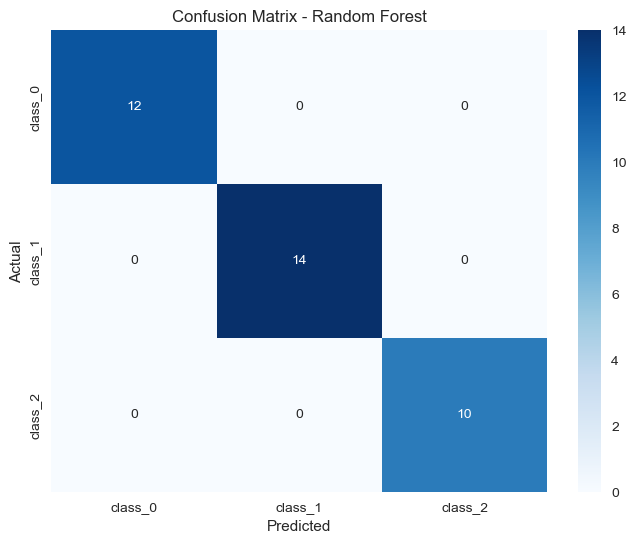


5. CROSS-VALIDATION
----------------------------------------
Cross-validation scores: [0.97222222 0.94444444 0.97222222 0.97142857 1.        ]
Mean CV accuracy: 0.9721 (+/- 0.0351)

6. FEATURE ANALYSIS
----------------------------------------
Top 5 most important features:
            feature  importance
9   color_intensity    0.187580
6        flavanoids    0.159561
12          proline    0.146799
0           alcohol    0.117913
10              hue    0.101538


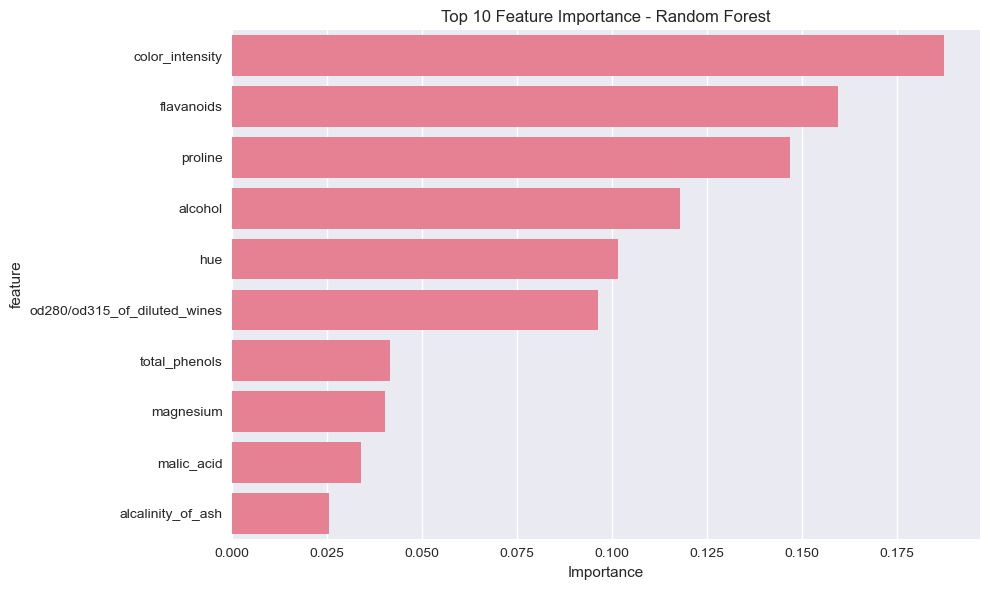


7. MODEL INTERPRETATION AND INSIGHTS
----------------------------------------
Model Performance Summary:
- Best Model: Random Forest
- Test Accuracy: 1.0000
- Cross-validation Accuracy: 0.9721 (+/- 0.0351)

Key Insights:
- The model can classify wine types with 100.0% accuracy
- Cross-validation shows consistent performance across different data splits
- The most important feature for classification is: color_intensity

8. CONCLUSION AND RECOMMENDATIONS
----------------------------------------
Project Summary:
- Successfully built a wine classification model
- Achieved 100.0% accuracy on test data
- Model is ready for deployment with proper validation

Recommendations:
- Consider collecting more data to improve model robustness
- Monitor model performance over time
- Consider ensemble methods for even better performance

🎉 Project completed successfully!


In [1]:
# TODO: Complete the following comprehensive data analysis project

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
from sklearn.datasets import load_wine
import warnings
warnings.filterwarnings('ignore')

# Set plotting style
plt.style.use('seaborn-v0_8')
sns.set_palette("husl")

print("=== COMPREHENSIVE DATA ANALYSIS PROJECT ===")
print("Project: Wine Quality Classification")
print("Objective: Build a machine learning model to classify wine quality")
print("=" * 50)

# 1. Data Loading and Initial Exploration
print("\n1. DATA LOADING AND EXPLORATION")
print("-" * 40)

# Load the wine dataset
wine = load_wine()
wine_df = pd.DataFrame(wine.data, columns=wine.feature_names)
wine_df['target'] = wine.target
wine_df['wine_type'] = wine.target_names[wine.target]

print(f"Dataset shape: {wine_df.shape}")
print(f"Features: {list(wine_df.columns[:-2])}")  # Exclude target and wine_type
print(f"Target classes: {wine.target_names}")

# TODO: Display basic information about the dataset
print(f"\nDataset Info:")
print(wine_df.info())
print(f"\nFirst 5 rows:")
print(wine_df.head())

# TODO: Display statistical summary
print(f"\nStatistical Summary:")
print(wine_df.describe())

# 2. Exploratory Data Analysis (EDA)
print(f"\n2. EXPLORATORY DATA ANALYSIS")
print("-" * 40)

# Check for missing values
print(f"Missing values:\n{wine_df.isnull().sum()}")

# Check data distribution
print(f"\nTarget distribution:")
print(wine_df['wine_type'].value_counts())

# TODO: Create visualizations for EDA
plt.figure(figsize=(15, 10))

# Distribution of target classes
plt.subplot(2, 3, 1)
wine_df['wine_type'].value_counts().plot(kind='bar', color='skyblue')
plt.title('Distribution of Wine Types')
plt.xlabel('Wine Type')
plt.ylabel('Count')
plt.xticks(rotation=45)

# Correlation heatmap
plt.subplot(2, 3, 2)
correlation_matrix = wine_df.select_dtypes(include=[np.number]).corr()
sns.heatmap(correlation_matrix, annot=False, cmap='coolwarm', center=0)
plt.title('Feature Correlation Heatmap')

# Box plot for a few key features
plt.subplot(2, 3, 3)
wine_df.boxplot(column=['alcohol', 'malic_acid', 'ash'], by='wine_type', ax=plt.gca())
plt.title('Key Features by Wine Type')
plt.suptitle('')  # Remove default title

# Scatter plot of two important features
plt.subplot(2, 3, 4)
colors = ['red', 'green', 'blue']
for i, wine_type in enumerate(wine.target_names):
    mask = wine_df['wine_type'] == wine_type
    plt.scatter(wine_df[mask]['alcohol'], wine_df[mask]['malic_acid'], 
                c=colors[i], label=wine_type, alpha=0.7)
plt.xlabel('Alcohol')
plt.ylabel('Malic Acid')
plt.title('Alcohol vs Malic Acid by Wine Type')
plt.legend()

# Feature importance (using Random Forest)
plt.subplot(2, 3, 5)
X = wine_df.drop(['target', 'wine_type'], axis=1)
y = wine_df['target']
rf_temp = RandomForestClassifier(n_estimators=100, random_state=42)
rf_temp.fit(X, y)
feature_importance = pd.DataFrame({
    'feature': X.columns,
    'importance': rf_temp.feature_importances_
}).sort_values('importance', ascending=True)
feature_importance.plot(x='feature', y='importance', kind='barh', ax=plt.gca())
plt.title('Feature Importance')
plt.xlabel('Importance')

# Distribution of alcohol content
plt.subplot(2, 3, 6)
wine_df['alcohol'].hist(bins=20, alpha=0.7, color='orange')
plt.title('Distribution of Alcohol Content')
plt.xlabel('Alcohol')
plt.ylabel('Frequency')

plt.tight_layout()
plt.show()

# 3. Data Preprocessing
print(f"\n3. DATA PREPROCESSING")
print("-" * 40)

# Separate features and target
X = wine_df.drop(['target', 'wine_type'], axis=1)
y = wine_df['target']

# TODO: Apply feature scaling
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)
X_scaled_df = pd.DataFrame(X_scaled, columns=X.columns)

print(f"Original features shape: {X.shape}")
print(f"Scaled features shape: {X_scaled.shape}")
print(f"Scaled features (first 5 rows):\n{X_scaled_df.head()}")

# Split the data
X_train, X_test, y_train, y_test = train_test_split(
    X_scaled, y, test_size=0.2, random_state=42, stratify=y
)

print(f"\nTraining set shape: {X_train.shape}")
print(f"Test set shape: {X_test.shape}")

# 4. Model Building and Evaluation
print(f"\n4. MODEL BUILDING AND EVALUATION")
print("-" * 40)

# TODO: Train multiple models
models = {
    'Logistic Regression': LogisticRegression(random_state=42),
    'Random Forest': RandomForestClassifier(n_estimators=100, random_state=42),
    'Gradient Boosting': GradientBoostingClassifier(random_state=42)
}

model_results = {}

for name, model in models.items():
    # Train the model
    model.fit(X_train, y_train)
    
    # Make predictions
    y_pred = model.predict(X_test)
    
    # Calculate accuracy
    accuracy = accuracy_score(y_test, y_pred)
    model_results[name] = accuracy
    
    print(f"{name} Accuracy: {accuracy:.4f}")

# TODO: Find the best model
best_model_name = max(model_results, key=model_results.get)
best_model = models[best_model_name]
print(f"\nBest model: {best_model_name} with accuracy: {model_results[best_model_name]:.4f}")

# Detailed evaluation of best model
y_pred_best = best_model.predict(X_test)
print(f"\nDetailed Classification Report for {best_model_name}:")
print(classification_report(y_test, y_pred_best, target_names=wine.target_names))

# Confusion Matrix
plt.figure(figsize=(8, 6))
cm = confusion_matrix(y_test, y_pred_best)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
            xticklabels=wine.target_names, yticklabels=wine.target_names)
plt.title(f'Confusion Matrix - {best_model_name}')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.show()

# 5. Cross-Validation
print(f"\n5. CROSS-VALIDATION")
print("-" * 40)

# TODO: Perform cross-validation
cv_scores = cross_val_score(best_model, X_scaled, y, cv=5, scoring='accuracy')
print(f"Cross-validation scores: {cv_scores}")
print(f"Mean CV accuracy: {cv_scores.mean():.4f} (+/- {cv_scores.std() * 2:.4f})")

# 6. Feature Analysis
print(f"\n6. FEATURE ANALYSIS")
print("-" * 40)

# TODO: Analyze feature importance
if hasattr(best_model, 'feature_importances_'):
    feature_importance = pd.DataFrame({
        'feature': X.columns,
        'importance': best_model.feature_importances_
    }).sort_values('importance', ascending=False)
    
    print(f"Top 5 most important features:")
    print(feature_importance.head())
    
    # Plot feature importance
    plt.figure(figsize=(10, 6))
    sns.barplot(data=feature_importance.head(10), x='importance', y='feature')
    plt.title(f'Top 10 Feature Importance - {best_model_name}')
    plt.xlabel('Importance')
    plt.tight_layout()
    plt.show()

# 7. Model Interpretation and Insights
print(f"\n7. MODEL INTERPRETATION AND INSIGHTS")
print("-" * 40)

print(f"Model Performance Summary:")
print(f"- Best Model: {best_model_name}")
print(f"- Test Accuracy: {model_results[best_model_name]:.4f}")
print(f"- Cross-validation Accuracy: {cv_scores.mean():.4f} (+/- {cv_scores.std() * 2:.4f})")

print(f"\nKey Insights:")
print(f"- The model can classify wine types with {model_results[best_model_name]:.1%} accuracy")
print(f"- Cross-validation shows consistent performance across different data splits")
if hasattr(best_model, 'feature_importances_'):
    top_feature = feature_importance.iloc[0]['feature']
    print(f"- The most important feature for classification is: {top_feature}")

# 8. Conclusion and Recommendations
print(f"\n8. CONCLUSION AND RECOMMENDATIONS")
print("-" * 40)

print(f"Project Summary:")
print(f"- Successfully built a wine classification model")
print(f"- Achieved {model_results[best_model_name]:.1%} accuracy on test data")
print(f"- Model is ready for deployment with proper validation")

print(f"\nRecommendations:")
print(f"- Consider collecting more data to improve model robustness")
print(f"- Monitor model performance over time")
print(f"- Consider ensemble methods for even better performance")

print(f"\n🎉 Project completed successfully!")
